Download status: 200
File size: 5988757 bytes
Number of districts: 33
Columns: ['D_CODE', 'S_NAME', 'S_CODE', 'D_NAME', 'geometry']


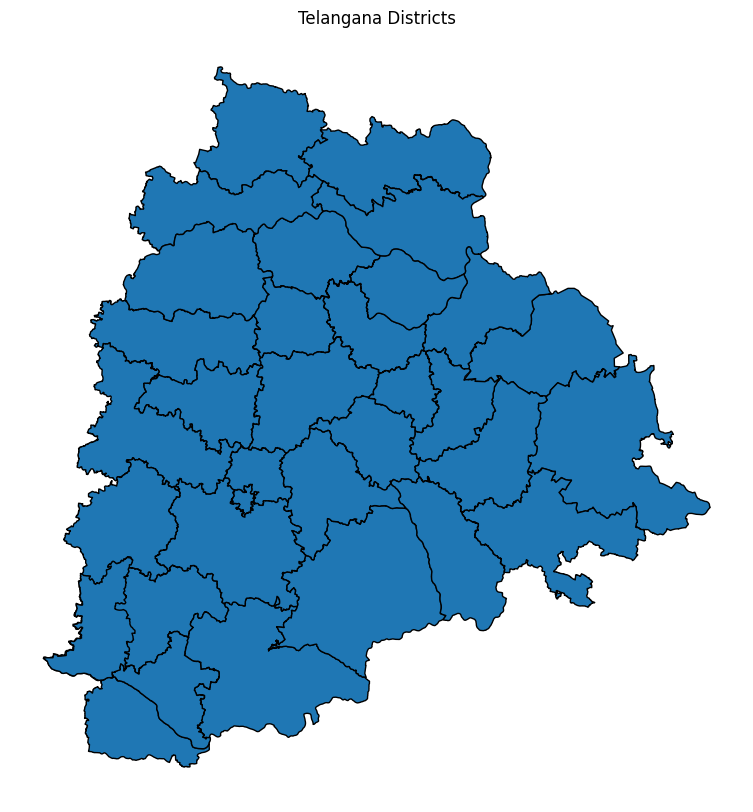

In [7]:
import requests
import geopandas as gpd
import matplotlib.pyplot as plt
from io import BytesIO

# Telangana 33-district GeoJSON
url = "https://raw.githubusercontent.com/Charan1845/hydro-vision/main/data/Telangana.geojson"

r = requests.get(url)

print("Download status:", r.status_code)
print("File size:", len(r.content), "bytes")

if r.status_code != 200:
    raise Exception("GeoJSON could not be downloaded.")

gdf = gpd.read_file(BytesIO(r.content))

print("Number of districts:", len(gdf))
print("Columns:", list(gdf.columns))

gdf.plot(figsize=(10, 10), edgecolor="black")
plt.title("Telangana Districts")
plt.axis("off")
plt.show()

In [8]:
# Use D_NAME as the district name
name_col = "D_NAME"

# Keep only district name and geometry
gdf = gdf[[name_col, "geometry"]].copy()

# Fix geometry if necessary
gdf["geometry"] = gdf.geometry.buffer(0)

districts = list(gdf[name_col])

# Create adjacency graph
adjacency = {district: [] for district in districts}

for i in range(len(gdf)):
    for j in range(i + 1, len(gdf)):

        if gdf.geometry.iloc[i].touches(gdf.geometry.iloc[j]):

            d1 = gdf[name_col].iloc[i]
            d2 = gdf[name_col].iloc[j]

            adjacency[d1].append(d2)
            adjacency[d2].append(d1)

print("Adjacency graph created successfully.")
print("Total districts:", len(districts))

Adjacency graph created successfully.
Total districts: 33


In [9]:
colors = ["Red", "Green", "Blue", "Yellow"]

color_assignment = {}

def is_safe(district, color):
    for neighbor in adjacency[district]:
        if color_assignment.get(neighbor) == color:
            return False
    return True


def map_coloring(index=0):

    if index == len(districts):
        return True

    district = districts[index]

    for color in colors:

        if is_safe(district, color):

            color_assignment[district] = color

            if map_coloring(index + 1):
                return True

            del color_assignment[district]

    return False


if map_coloring():
    print("Map coloring successful!")
else:
    print("No valid coloring found.")

Map coloring successful!


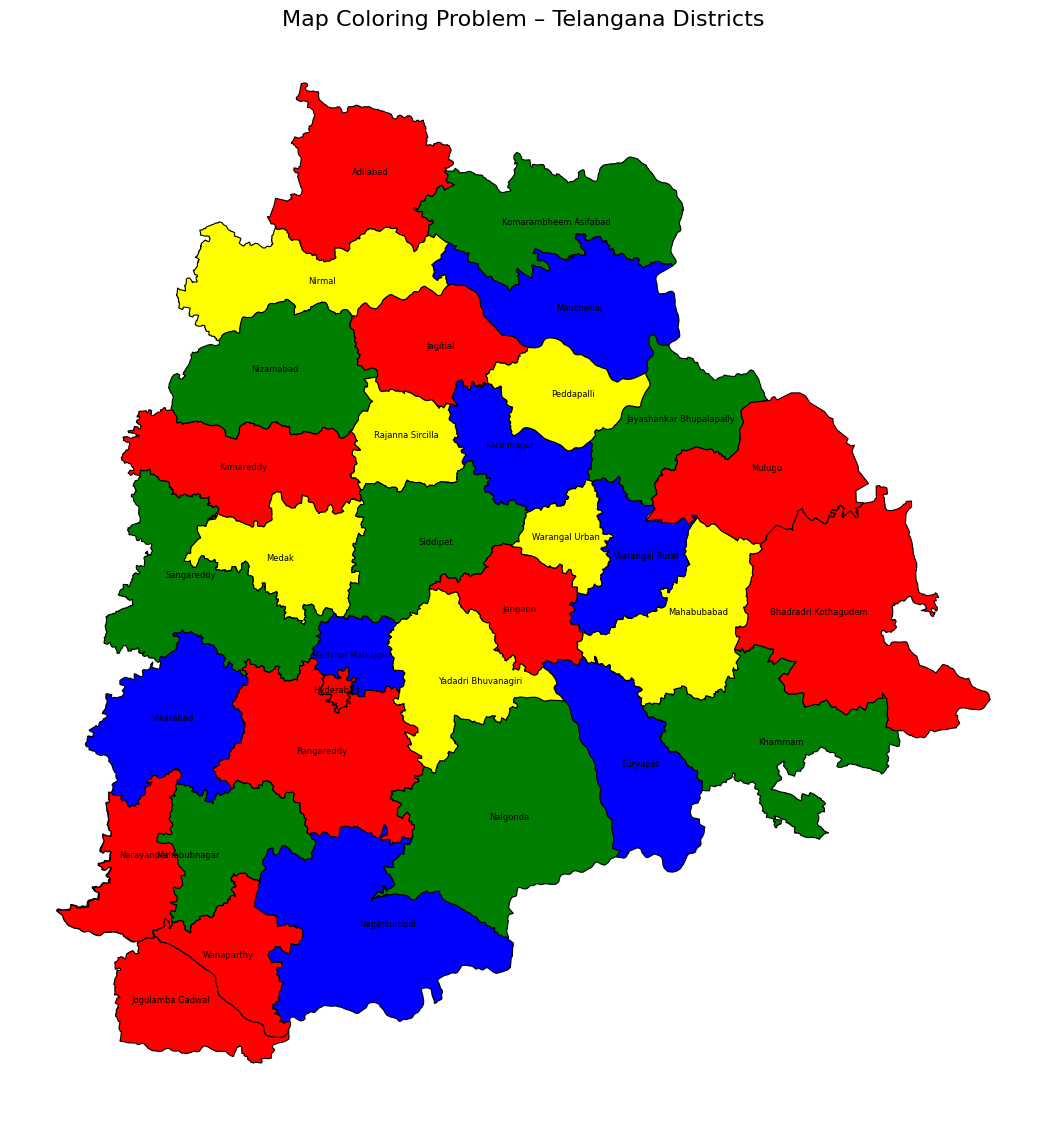

In [10]:
color_map = {
    "Red": "red",
    "Green": "green",
    "Blue": "blue",
    "Yellow": "yellow"
}

gdf["Color"] = gdf[name_col].map(color_assignment)
gdf["PlotColor"] = gdf["Color"].map(color_map)

fig, ax = plt.subplots(figsize=(14, 14))

gdf.plot(
    ax=ax,
    color=gdf["PlotColor"],
    edgecolor="black",
    linewidth=0.8
)

# Add district names
for _, row in gdf.iterrows():

    point = row.geometry.representative_point()

    ax.text(
        point.x,
        point.y,
        row[name_col],
        fontsize=6,
        ha="center",
        va="center"
    )

plt.title("Map Coloring Problem – Telangana Districts", fontsize=16)
plt.axis("off")
plt.show()

In [12]:
valid = True

for district in adjacency:
    for neighbor in adjacency[district]:

        if color_assignment[district] == color_assignment[neighbor]:
            print("Conflict:", district, "-", neighbor)
            valid = False

if valid:
    print("VALID SOLUTION")
    print("All adjacent districts have different colors.")
else:
    print("INVALID SOLUTION")

VALID SOLUTION
All adjacent districts have different colors.
